Importing:

In [37]:
import  pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

Settting style and paths:

In [38]:
sns.set_style("darkgrid")
plt.rcParams["figure.figsize"] = (12, 6)

DATA_DIR = Path("../data/processed") 

Loading data:

In [39]:
train = pd.read_csv(DATA_DIR / "train.csv")
val = pd.read_csv(DATA_DIR / "val.csv")
test = pd.read_csv(DATA_DIR / "test.csv")

print("dataset sizes:")
print(f"train: {len(train):,} rows")
print(f"val: {len(val):,} rows")
print(f"test: {len(test):,} rows")

dataset sizes:
train: 35,364 rows
val: 7,660 rows
test: 15,990 rows


These dataset proportions should be adequate for my first version. I can always tweak them later

Basic Data Overview:

In [40]:
print("\n=== Train Set Info ===")
print(train.info())
print("\n=== Train Set Shape ===")
print(f"Rows: {train.shape[0]}, Columns: {train.shape[1]}")
print("\n=== First 5 Rows ===")
display(train.head())
print("\n=== Column Names ===")
print(train.columns.tolist())


=== Train Set Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35364 entries, 0 to 35363
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  35364 non-null  int64  
 1   round                 35364 non-null  object 
 2   best_of               35364 non-null  int64  
 3   player_hand           35364 non-null  object 
 4   player_ht             35320 non-null  float64
 5   player_ioc            35364 non-null  object 
 6   player_age            35364 non-null  float64
 7   player_rank           35364 non-null  float64
 8   player_rank_points    35364 non-null  float64
 9   opponent_hand         35364 non-null  object 
 10  opponent_ht           35320 non-null  float64
 11  opponent_ioc          35364 non-null  object 
 12  opponent_age          35364 non-null  float64
 13  opponent_rank         35364 non-null  float64
 14  opponent_rank_points  35364 non-null  float64


,year,round,best_of,player_hand,player_ht,player_ioc,player_age,player_rank,player_rank_points,opponent_hand,...,rank_diff,age_diff,height_diff,rank_points_diff,surface_Grass,surface_Hard,tourney_level_F,tourney_level_G,tourney_level_M,tourney_level_O
0,2013,R32,3,R,180.0,TPE,29.4,60.0,754.0,R,...,17.0,5.8,-16.0,-183.0,False,True,False,False,False,False
1,2013,R32,3,R,196.0,FRA,23.6,43.0,937.0,R,...,-17.0,-5.8,16.0,183.0,False,True,False,False,False,False
2,2013,R32,3,R,185.0,SVK,25.1,48.0,872.0,R,...,-9.0,-5.9,2.0,103.0,False,True,False,False,False,False
3,2013,R32,3,R,183.0,ITA,31.0,57.0,769.0,R,...,9.0,5.9,-2.0,-103.0,False,True,False,False,False,False
4,2013,R32,3,L,188.0,BRA,25.0,32.0,1112.0,R,...,-18.0,3.0,8.0,269.0,False,True,False,False,False,False



=== Column Names ===
['year', 'round', 'best_of', 'player_hand', 'player_ht', 'player_ioc', 'player_age', 'player_rank', 'player_rank_points', 'opponent_hand', 'opponent_ht', 'opponent_ioc', 'opponent_age', 'opponent_rank', 'opponent_rank_points', 'label', 'month', 'rank_diff', 'age_diff', 'height_diff', 'rank_points_diff', 'surface_Grass', 'surface_Hard', 'tourney_level_F', 'tourney_level_G', 'tourney_level_M', 'tourney_level_O']


Target Variable Analysis:

In [41]:
print("\n=== Label Distribution ===")
print(train['label'].value_counts())
print(f"\nWin rate (label=1): {train['label'].mean():.2%}")


=== Label Distribution ===
label
1    17682
0    17682
Name: count, dtype: int64

Win rate (label=1): 50.00%


This 50/50 split is by design, not random. Since we encoded as winner = 1 and loser = 0, every match appears twice, meaning, win rate will always be 50%. This ensures the model sees the balanced win/loss examples. It's important to keep this in mind later on when we train the model, as the train dataset is doubled.

Missing Data Check:

In [46]:
print("\n=== Missing Data ===")
missing = train.isnull().sum()
missing_pct = (missing / len(train)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
if len(missing_df) > 0:
    print(missing_df)
else:
    print("No missing data!")


=== Missing Data ===
             Missing Count  Missing %
height_diff             88   0.248841
player_ht               44   0.124420
opponent_ht             44   0.124420


11. TRAIN/VAL/TEST COMPARISON


=== Dataset Comparison ===
            Train     Val     Test
Size      35364.0  7660.0  15990.0
Win Rate      0.5     0.5      0.5


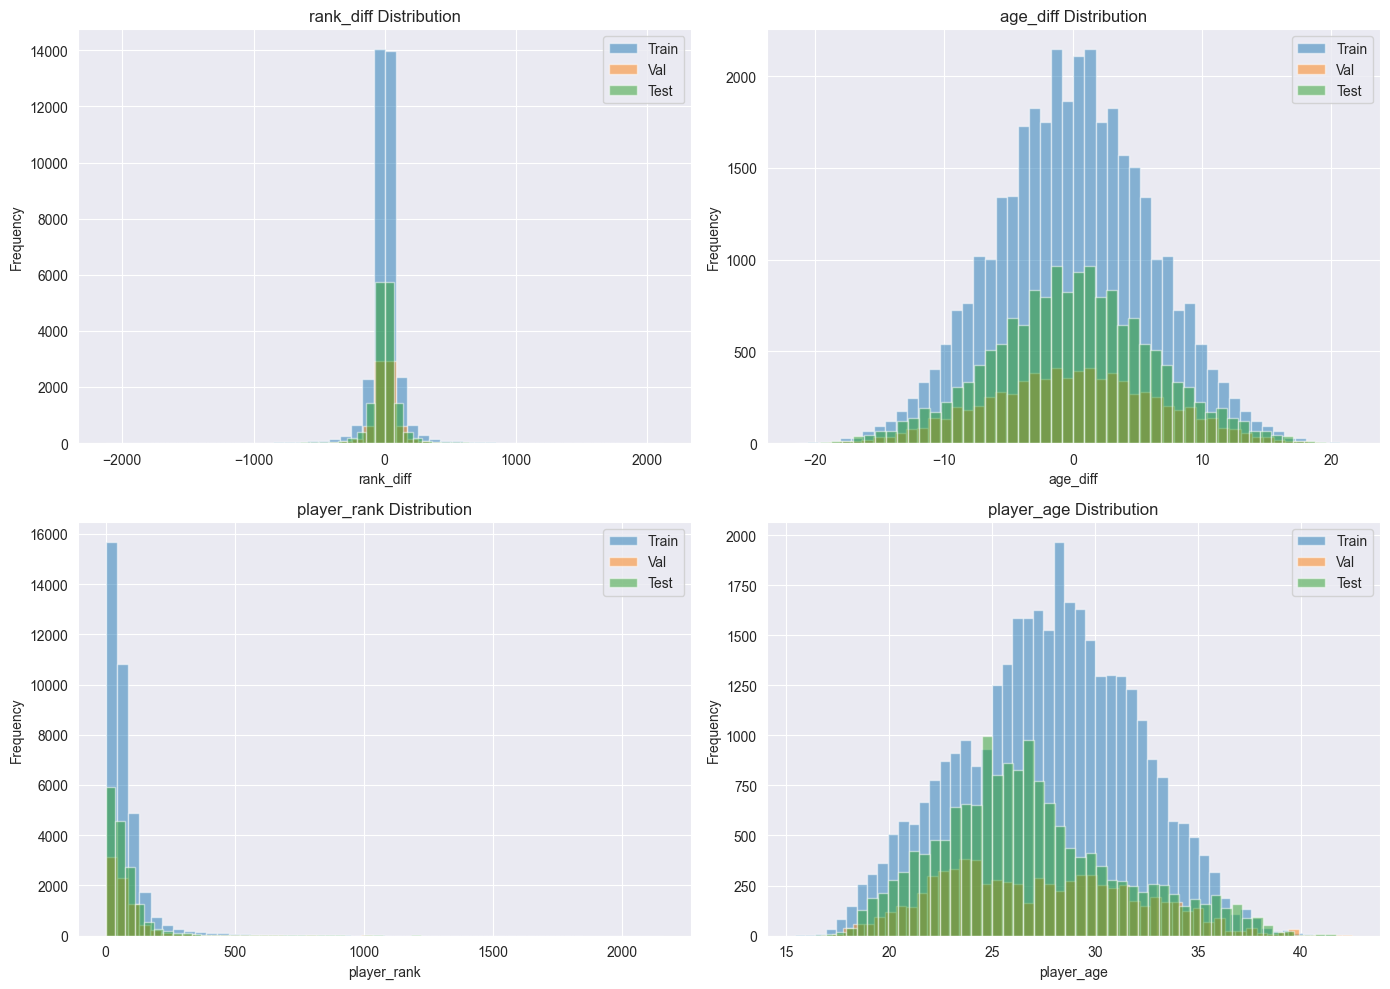

In [47]:
print("\n=== Dataset Comparison ===")
comparison = pd.DataFrame({
    'Train': [len(train), train['label'].mean()],
    'Val': [len(val), val['label'].mean()],
    'Test': [len(test), test['label'].mean()]
}, index=['Size', 'Win Rate'])
print(comparison)

# Feature distribution comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, feature in enumerate(['rank_diff', 'age_diff', 'player_rank', 'player_age']):
    ax = axes[i // 2, i % 2]
    train[feature].hist(alpha=0.5, label='Train', bins=50, ax=ax)
    val[feature].hist(alpha=0.5, label='Val', bins=50, ax=ax)
    test[feature].hist(alpha=0.5, label='Test', bins=50, ax=ax)
    ax.set_title(f'{feature} Distribution')
    ax.legend()
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

Key Insights & Summary

In [ ]:
print("\n=== Key Insights ===")
print(f"1. Dataset is {'balanced' if 0.45 < train['label'].mean() < 0.55 else 'imbalanced'} (50/50 split by design)")
print(f"2. Rank difference range: {train['rank_diff'].min():.0f} to {train['rank_diff'].max():.0f}")
print(f"3. Age difference range: {train['age_diff'].min():.1f} to {train['age_diff'].max():.1f}")
print(f"4. Missing data: {train.isnull().sum().sum()} total missing values (mostly height-related)")
print(f"5. Feature importance analysis shows which features the model actually uses (see above)")


=== Key Insights ===
1. Dataset is balanced
2. Strongest correlation with label: label
3. Rank difference range: -2125 to 2125
4. Age difference range: -21.5 to 21.5
